# Phase 2 — Dataset & DataLoader
Build a PyTorch `Dataset` class for Nutrition5K, define train/val/test splits, apply image transforms, and verify a batch loads correctly.

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T

# GPU check
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else
                      'cpu')
print(f'✓ Using device: {device}')

✓ Using device: cuda


In [3]:
# ── Auto-detect environment and set data paths ────────────────────────────────
KAGGLE_ROOT = '/kaggle/input'
LOCAL_DATA  = 'data/archive'

if os.path.exists(KAGGLE_ROOT):
    data_dir = None
    for root, dirs, files in os.walk(KAGGLE_ROOT):
        if 'dish_nutrition_values.csv' in files:
            data_dir = root
            break
    if data_dir is None:
        raise FileNotFoundError('Nutrition5K dataset not found under /kaggle/input.')
    print(f'✓ Kaggle: dataset found at {data_dir}')
else:
    data_dir = LOCAL_DATA
    print(f'✓ Local: using {data_dir}')

img_dir         = os.path.join(data_dir, 'imagery/realsense_overhead')
nutrition_csv   = os.path.join(data_dir, 'dish_nutrition_values.csv')
print('✓ Paths set')

✓ Kaggle: dataset found at /kaggle/input/datasets/gillesokhin/nutrition5k-dataset
✓ Paths set


In [4]:
# ── Load & inspect nutrition labels ──────────────────────────────────────────
df = pd.read_csv(nutrition_csv)
print(f'Rows: {len(df)}  |  Columns: {list(df.columns)}')
display(df.head(3))

Rows: 4768  |  Columns: ['dish_id', 'calories', 'mass', 'fat', 'carb', 'protein']


,dish_id,calories,mass,fat,carb,protein
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593


In [5]:
# ── Identify key columns ──────────────────────────────────────────────────────
# Dish ID column (first column)
dish_id_col = df.columns[0]

# Target columns — adjust names if your CSV differs
# We'll try to auto-detect calories, fat, protein, carbs
def find_col(df, keywords):
    for kw in keywords:
        match = next((c for c in df.columns if kw in c.lower()), None)
        if match:
            return match
    return None

cal_col     = find_col(df, ['calor'])
fat_col     = find_col(df, ['fat'])
protein_col = find_col(df, ['protein'])
carb_col    = find_col(df, ['carb'])

TARGET_COLS = [c for c in [cal_col, fat_col, protein_col, carb_col] if c]
print(f'Dish ID column : {dish_id_col}')
print(f'Target columns : {TARGET_COLS}')

Dish ID column : dish_id
Target columns : ['calories', 'fat', 'protein', 'carb']


In [6]:
# ── Filter to dishes that have an image folder WITH at least one image ──────
available_dishes = set(os.listdir(img_dir))

def has_images(dish_id):
    path = os.path.join(img_dir, dish_id)
    if not os.path.isdir(path):
        return False
    return any(f.lower().endswith(('.jpg', '.png')) for f in os.listdir(path))

df_valid = df[df[dish_id_col].isin(available_dishes)].reset_index(drop=True)
df_valid = df_valid[df_valid[dish_id_col].apply(has_images)].reset_index(drop=True)

print(f'Total rows in CSV          : {len(df)}')
print(f'Rows with folder + images  : {len(df_valid)}')
print(f'Dropped                    : {len(df) - len(df_valid)}')


Total rows in CSV          : 4768
Rows with folder + images  : 3247
Dropped                    : 1521


In [7]:
# ── Image Transforms ─────────────────────────────────────────────────────────
IMG_SIZE = 224  # standard input size for most pretrained CNNs

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                std =[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

print(f'✓ Transforms defined (input size: {IMG_SIZE}x{IMG_SIZE})')

✓ Transforms defined (input size: 224x224)


In [8]:
# ── Nutrition5K PyTorch Dataset ───────────────────────────────────────────────
class Nutrition5KDataset(Dataset):
    """
    Returns (image_tensor, target_tensor) for each dish.
    target_tensor contains [calories, fat, protein, carbs] (or whichever
    target_cols are available).
    """
    def __init__(self, df, img_dir, dish_id_col, target_cols, transform=None):
        self.df          = df.reset_index(drop=True)
        self.img_dir     = img_dir
        self.dish_id_col = dish_id_col
        self.target_cols = target_cols
        self.transform   = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        dish_id = row[self.dish_id_col]

        # Load the first RGB image in the dish folder
        dish_path = os.path.join(self.img_dir, dish_id)
        imgs = sorted([f for f in os.listdir(dish_path)
                       if f.lower().endswith(('.jpg', '.png'))])
        if not imgs:
            raise FileNotFoundError(f'No images found in {dish_path}')
        img = Image.open(os.path.join(dish_path, imgs[0])).convert('RGB')

        if self.transform:
            img = self.transform(img)

        targets = torch.tensor(row[self.target_cols].values.astype(float),
                               dtype=torch.float32)
        return img, targets

print('✓ Nutrition5KDataset class defined')

✓ Nutrition5KDataset class defined


In [9]:
# ── Train / Val / Test Split (80 / 10 / 10) ───────────────────────────────────
torch.manual_seed(42)

n       = len(df_valid)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)
n_test  = n - n_train - n_val

# Shuffle indices
indices = torch.randperm(n).tolist()
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

df_train = df_valid.iloc[train_idx].reset_index(drop=True)
df_val   = df_valid.iloc[val_idx].reset_index(drop=True)
df_test  = df_valid.iloc[test_idx].reset_index(drop=True)

print(f'Train: {len(df_train)}  |  Val: {len(df_val)}  |  Test: {len(df_test)}')

Train: 2597  |  Val: 324  |  Test: 326


In [10]:
# ── Create Datasets & DataLoaders ────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 2  # set to 0 on Windows if you get errors

train_dataset = Nutrition5KDataset(df_train, img_dir, dish_id_col, TARGET_COLS, transform=train_transform)
val_dataset   = Nutrition5KDataset(df_val,   img_dir, dish_id_col, TARGET_COLS, transform=val_transform)
test_dataset  = Nutrition5KDataset(df_test,  img_dir, dish_id_col, TARGET_COLS, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'✓ DataLoaders ready')
print(f'  Train batches: {len(train_loader)}')
print(f'  Val batches  : {len(val_loader)}')
print(f'  Test batches : {len(test_loader)}')

✓ DataLoaders ready
  Train batches: 82
  Val batches  : 11
  Test batches : 11


In [11]:
# ── Sanity Check: Load One Batch ─────────────────────────────────────────────
images, targets = next(iter(train_loader))
print(f'Image batch shape  : {images.shape}')   # [B, 3, 224, 224]
print(f'Target batch shape : {targets.shape}')  # [B, num_targets]
print(f'Target columns     : {TARGET_COLS}')
print(f'Sample targets (first 3 rows):\n{targets[:3]}')

Image batch shape  : torch.Size([32, 3, 224, 224])
Target batch shape : torch.Size([32, 4])
Target columns     : ['calories', 'fat', 'protein', 'carb']
Sample targets (first 3 rows):
tensor([[9.2781e+02, 2.8737e+01, 7.7984e+01, 8.5054e+01],
        [3.3053e+02, 1.5102e+01, 3.2766e+01, 1.5042e+01],
        [3.0545e+01, 2.9136e+00, 5.7582e-01, 9.4853e-01]])


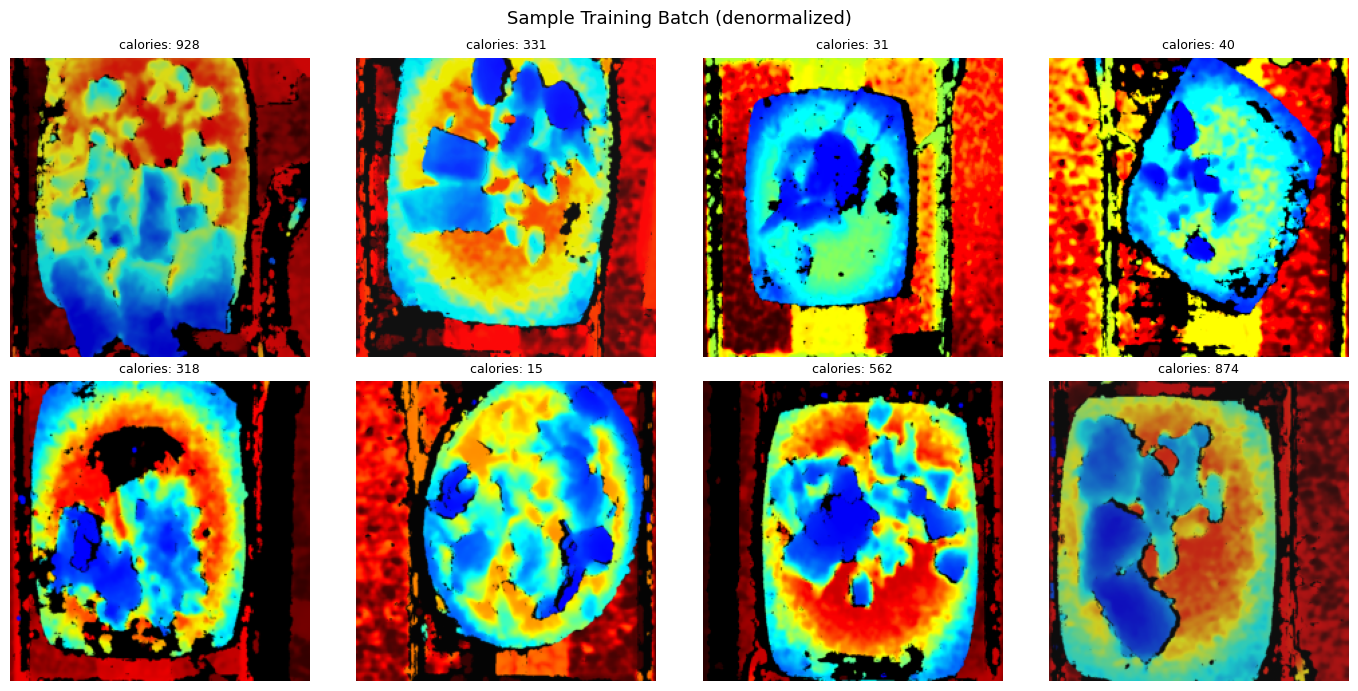

In [12]:
# ── Visualize a Batch (denormalized) ─────────────────────────────────────────
def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

n_show = min(8, len(images))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(n_show):
    img_disp = denormalize(images[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img_disp)
    axes[i].axis('off')
    if cal_col:
        cal_idx = TARGET_COLS.index(cal_col)
        axes[i].set_title(f'{cal_col}: {targets[i, cal_idx]:.0f}', fontsize=9)

plt.suptitle('Sample Training Batch (denormalized)', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# ── Phase 2 Summary ──────────────────────────────────────────────────────────
print('=' * 60)
print('PHASE 2 SUMMARY')
print('=' * 60)
print(f'  Dataset size  : {len(df_valid)} dishes')
print(f'  Train/Val/Test: {len(df_train)} / {len(df_val)} / {len(df_test)}')
print(f'  Image size    : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Targets       : {TARGET_COLS}')
print(f'  Device        : {device}')
print('=' * 60)
print('✓ Phase 2 complete — ready for Phase 3: Model')

PHASE 2 SUMMARY
  Dataset size  : 3247 dishes
  Train/Val/Test: 2597 / 324 / 326
  Image size    : 224x224
  Batch size    : 32
  Targets       : ['calories', 'fat', 'protein', 'carb']
  Device        : cuda
✓ Phase 2 complete — ready for Phase 3: Model
